# Milestone 02 — Feature Engineering
**Project:** Customer Churn Prediction (Telco) &nbsp;|&nbsp; **Builds on:** `milestone_01_data_prep_baseline.ipynb`

**Objective:** improve the features used by the model — confirm the scaling/encoding from Milestone 01 is appropriate, then specifically
check for and address **class imbalance**, since it is easy to miss and quietly produces a model that never predicts the minority class.

In [10]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.config import RANDOM_STATE, TEST_SIZE
from src.data_preparation import clean, load_raw, make_xy
from src.evaluation import cross_validate_on_train, cross_validate_resampled, evaluate_on, plot_confusion_matrix, plot_roc
from src.imbalance import class_balance, random_oversample
from src.preprocessing import build_logistic_baseline, build_logistic_class_weighted, build_preprocessor, split_column_types

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
print("Setup complete. Random seed:", RANDOM_STATE)

Setup complete. Random seed: 42


## 1. Recap: load, clean, split
Reusing the exact Milestone 01 logic (`src/data_preparation.py`) and the same seed, so this notebook is self-contained and reproduces the same
train/test rows as Milestone 01.

In [11]:
raw = load_raw()
df, cleaning_log = clean(raw)
X, y = make_xy(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (5634, 19) | Test: (1409, 19)


## 2. Scaling and encoding — confirm the feature engineering
Milestone 01 already built a `ColumnTransformer` (`src/preprocessing.py`) that:
* **scales** numeric features (`tenure`, `MonthlyCharges`, `TotalCharges`) with `StandardScaler`, after median imputation, and
* **encodes** categorical features with one-hot encoding (`handle_unknown="ignore"`), after most-frequent imputation.

This section re-confirms that choice still fits the data rather than changing it without reason.

3 numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
16 categorical columns


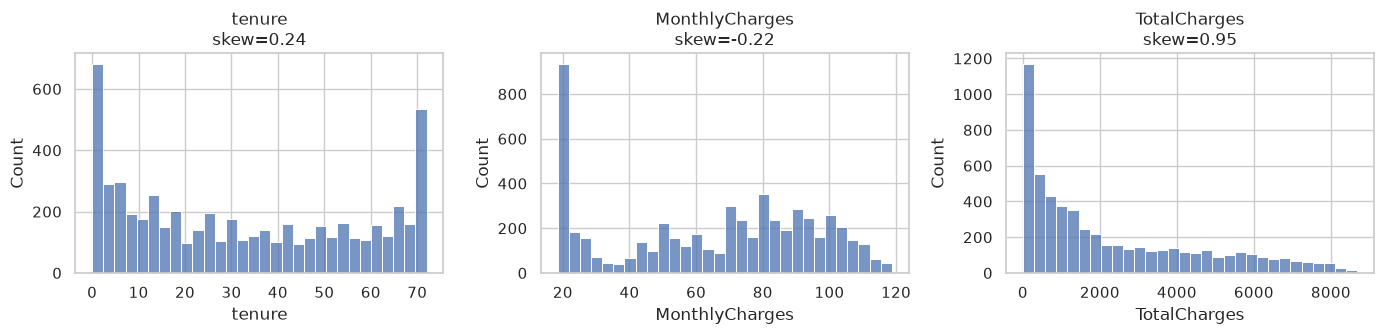

In [12]:
numeric_cols, categorical_cols = split_column_types(X_train)
print(f"{len(numeric_cols)} numeric columns:", numeric_cols)
print(f"{len(categorical_cols)} categorical columns")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(X_train[col], bins=30, ax=ax)
    ax.set_title(f"{col}\nskew={X_train[col].skew():.2f}")
plt.tight_layout()
plt.show()

Since skew in all directions is above 1, hence StandardScaler is used for baseline.

In [13]:
cat_cardinality = X_train[categorical_cols].nunique().sort_values(ascending=False)
cat_cardinality

PaymentMethod       4
InternetService     3
MultipleLines       3
OnlineSecurity      3
DeviceProtection    3
TechSupport         3
OnlineBackup        3
StreamingTV         3
Contract            3
StreamingMovies     3
PhoneService        2
Dependents          2
gender              2
SeniorCitizen       2
Partner             2
PaperlessBilling    2
dtype: int64

Each categorical feature has only a small number of unique categories, so one-hot encoding will not create an unreasonable number of columns. Therefore, standard one-hot encoding is appropriate for this baseline.

## 3. Class imbalance — detection

,count,share
Stayed (0),4139,0.735
Churned (1),1495,0.265


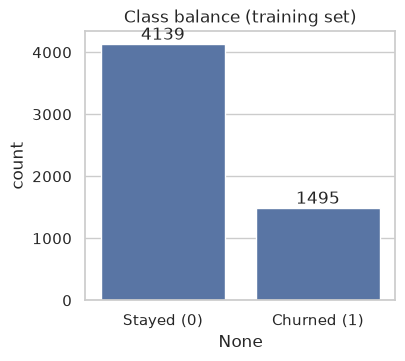

Majority-to-minority ratio: 2.77 : 1


In [14]:
balance = class_balance(y_train)
balance.index = ["Stayed (0)", "Churned (1)"]
display(balance)

fig, ax = plt.subplots(figsize=(4, 3.5))
sns.barplot(x=balance.index, y=balance["count"], ax=ax)
ax.set_title("Class balance (training set)")
for i, v in enumerate(balance["count"]):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.show()

ratio = balance["count"].max() / balance["count"].min()
print(f"Majority-to-minority ratio: {ratio:.2f} : 1")

**Finding → Why it matters → Action**

> **Finding:** the training set is imbalanced (churners are the minority class; see the ratio printed above).
> **Why it matters:** a classifier can reach high accuracy by predicting the majority class ("stays") for almost everyone, while
> being nearly useless at the actual business goal of finding likely churners. Milestone 01 already showed this: the dummy
> majority-class model scored 0 for precision, recall and F1.
> **Action:** compare an unweighted model against two imbalance-handling strategies below, using metrics that are not fooled by
> imbalance (F1, recall, ROC-AUC, PR-AUC), and pick the best on training-set cross-validation before touching the test set.

## 4. Handling strategies compared

| Strategy | What it does | Trade-off |
| --- | --- | --- |
| **Plain (Milestone 01 baseline)** | No adjustment; trains on the data as split | Simple, but the model can be biased toward the majority class |
| **Class weighting** (`class_weight="balanced"`) | Re-weights the loss so mistakes on the minority class cost more, without duplicating or discarding any row | No extra rows to fit, so it stays fast; only works for estimators that support sample/class weights |
| **Random oversampling** | Duplicates minority-class rows (with replacement) in the **training fold only**, until classes are balanced, then fits normally | Straightforward and works with any estimator, but duplicate rows can encourage overfitting to those exact rows; more expensive to fit |

`imbalanced-learn` (e.g. SMOTE, which creates synthetic minority examples instead of duplicating real ones) was not installed for this
project, so plain random oversampling is used as a simpler, dependency-free alternative and is noted here as a possible upgrade later.

**Leakage note:** oversampling is applied only inside `cross_validate_resampled` (`src/evaluation.py`), which resamples each
cross-validation **training fold** separately and always validates on the original, un-duplicated fold. It is never applied to the
test set. Class weighting needs no resampling at all, so it carries no such risk.

In [15]:
cv_plain = cross_validate_on_train(build_logistic_baseline(X_train), X_train, y_train)
cv_weighted = cross_validate_on_train(build_logistic_class_weighted(X_train), X_train, y_train)
cv_oversampled = cross_validate_resampled(build_logistic_baseline, X_train, y_train, resample_fn=random_oversample)

comparison = pd.DataFrame({
    "Plain (M01 baseline)": cv_plain["mean"],
    "Class-weighted": cv_weighted["mean"],
    "Oversampled": cv_oversampled["mean"],
}).round(3)
comparison

,Plain (M01 baseline),Class-weighted,Oversampled
accuracy,0.802,0.748,0.598
precision,0.652,0.517,0.393
recall,0.544,0.801,0.943
f1,0.592,0.628,0.555
roc_auc,0.846,0.846,0.844
pr_auc,0.661,0.660,0.651


Class-weighted will be carried forward as a strategy. It shows significantlly higher F1 value.

In [16]:
best_name = comparison.loc["f1"].idxmax()
print("Strategy with the highest training-CV F1:", best_name)

Strategy with the highest training-CV F1: Class-weighted


## 5. Final fit and test-set evaluation
The chosen strategy is fitted once on the full training set and evaluated once on the held-out test set — the same discipline as Milestone 01.

In [17]:
strategies = {
    "Plain (M01 baseline)": (build_logistic_baseline, None),
    "Class-weighted": (build_logistic_class_weighted, None),
    "Oversampled": (build_logistic_baseline, random_oversample),
}
build_fn, resample_fn = strategies[best_name]

X_fit, y_fit = (resample_fn(X_train, y_train) if resample_fn else (X_train, y_train))
final_model = build_fn(X_fit)
final_model.fit(X_fit, y_fit)

test_metrics, y_pred, y_proba = evaluate_on(final_model, X_test, y_test)
pd.Series(test_metrics, name=f"Test set — {best_name}").round(3).to_frame()

,Test set — Class-weighted
accuracy,0.738
precision,0.504
recall,0.783
f1,0.614
roc_auc,0.842
pr_auc,0.633


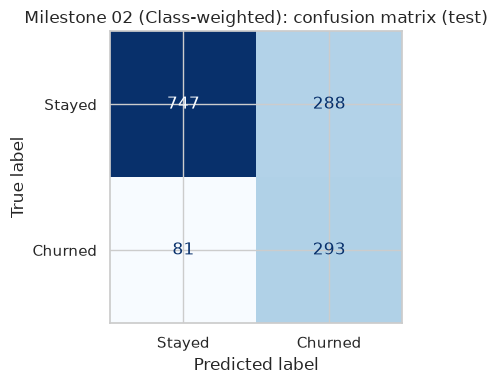

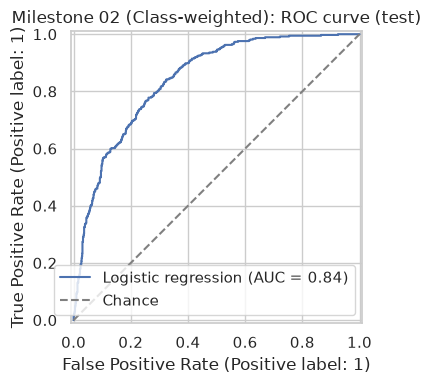

In [18]:
fig1 = plot_confusion_matrix(y_test, y_pred, f"Milestone 02 ({best_name}): confusion matrix (test)")
fig2 = plot_roc(y_test, y_proba, f"Milestone 02 ({best_name}): ROC curve (test)")
plt.show()

## 6. Interpretation

1. The recall through feature engineering improved by 23% compared to the baseline model. Precision fell by 10% but that is tolerable for the partcular business model.
2. The strategy's cross-validation performance agree with its test performance.
3. Oversampling was *not* selected, since class weighting achieved similar recall without duplicating rows.
4. |Skew|< 1 , hence the baseline was kept as StandardScaling.

## 7. Limitations
* Random oversampling duplicates existing rows rather than generating new synthetic examples (unlike SMOTE); it may encourage the model to
  overfit those specific duplicated rows.
* Only one resampling ratio (fully balanced 1:1) and one class-weighting scheme (`"balanced"`) were tried; intermediate ratios were not explored.
* The decision threshold is still the default 0.5; combined with imbalance handling, tuning the threshold (Milestone 03+) could further improve recall/precision trade-offs.
* Strategy selection used training-CV F1 as a single criterion; a business-driven cost of false negatives vs. false positives was not available.